In [32]:
#import all Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
#read the dataset
df=pd.read_csv("Dynamic_pricing.csv")

In [34]:
#information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [35]:
#First five rows of the dataset
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [36]:
#Last five rows of the dataset
df.tail()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
995,33,23,Urban,Gold,24,4.21,Morning,Premium,11,91.389526
996,84,29,Urban,Regular,92,4.55,Morning,Premium,94,424.155987
997,44,6,Suburban,Gold,80,4.13,Night,Premium,40,157.364830
998,53,27,Suburban,Regular,78,3.63,Night,Premium,58,279.095048
999,78,63,Rural,Gold,14,4.21,Afternoon,Economy,147,655.065106


In [37]:
#Unique values in each column
df.nunique()

Number_of_Riders             81
Number_of_Drivers            79
Location_Category             3
Customer_Loyalty_Status       3
Number_of_Past_Rides        101
Average_Ratings             151
Time_of_Booking               4
Vehicle_Type                  2
Expected_Ride_Duration      171
Historical_Cost_of_Ride    1000
dtype: int64

In [38]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Number_of_Riders', 'Number_of_Drivers', 'Location_Category', 'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings', 'Time_of_Booking', 'Vehicle_Type', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']


In [39]:
#check null values
df.isnull().sum()

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

In [40]:
#check for duplicate values
df.duplicated().sum()

np.int64(0)

In [41]:
#rows and columns of dataset
df.shape

(1000, 10)

In [42]:
#statistical measures of the dataset
df.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


In [ ]:
#separating numerical and categorical columns
num_cols=df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=df.select_dtypes(exclude=[np.number]).columns.tolist() 
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Number_of_Riders', 'Number_of_Drivers', 'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']
Categorical columns: ['Location_Category_Suburban', 'Location_Category_Urban', 'Time_of_Booking_Evening', 'Time_of_Booking_Morning', 'Time_of_Booking_Night', 'Vehicle_Type_Premium']


In [ ]:
#Mapping the categorical columns

# 1. Label encoding with map
loyalty_mapping = {"Regular": 0, "Silver": 1, "Gold": 2}
df["Customer_Loyalty_Status"] = df["Customer_Loyalty_Status"].map(loyalty_mapping)

# 2. One-hot encoding with pandas
df = pd.get_dummies(df, columns=["Location_Category", "Time_of_Booking", "Vehicle_Type"], drop_first=True)

# Check result
print(df.head())
print("\nFinal Shape:", df.shape)



   Number_of_Riders  Number_of_Drivers  Customer_Loyalty_Status  \
0                90                 45                        1   
1                58                 39                        1   
2                42                 31                        1   
3                89                 28                        0   
4                78                 22                        0   

   Number_of_Past_Rides  Average_Ratings  Expected_Ride_Duration  \
0                    13             4.47                      90   
1                    72             4.06                      43   
2                     0             3.99                      76   
3                    67             4.31                     134   
4                    74             3.77                     149   

   Historical_Cost_of_Ride  Location_Category_Suburban  \
0               284.257273                       False   
1               173.874753                        True   
2             

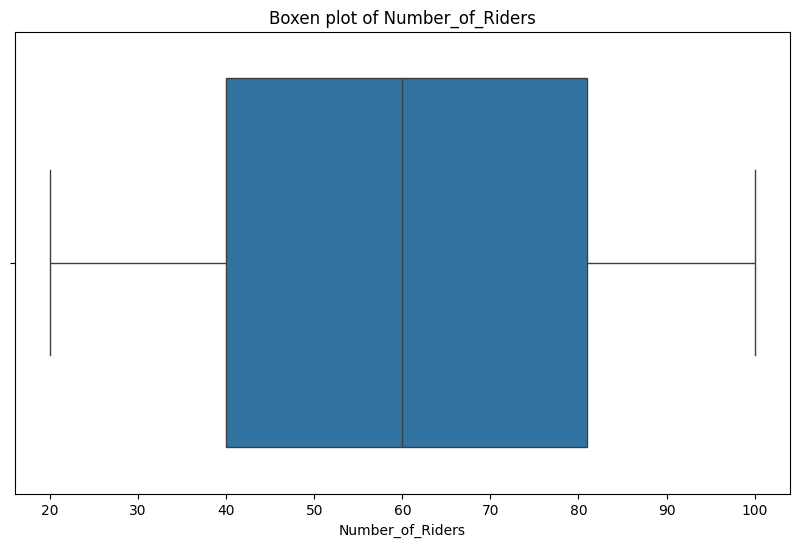

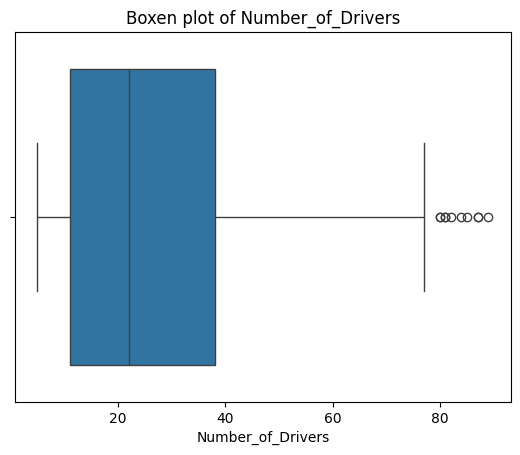

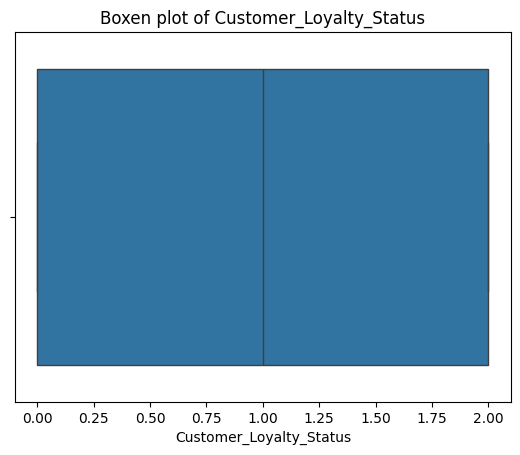

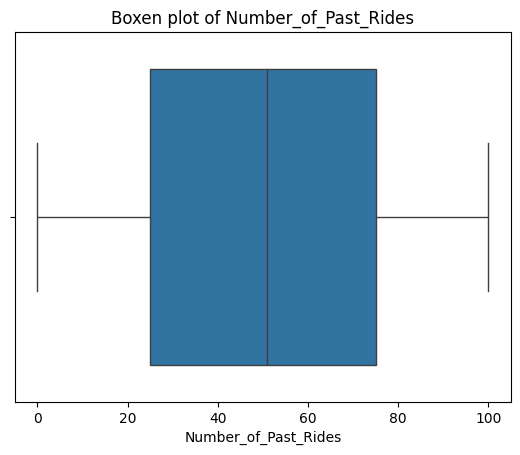

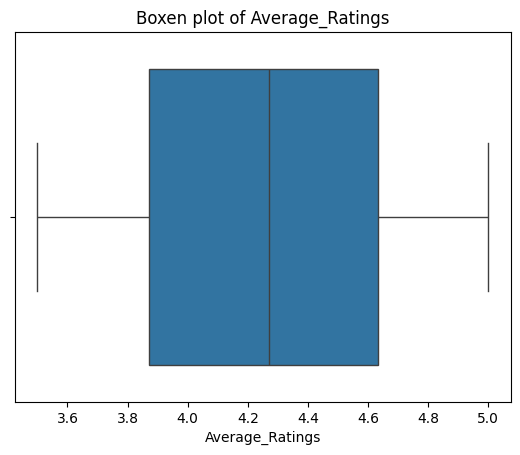

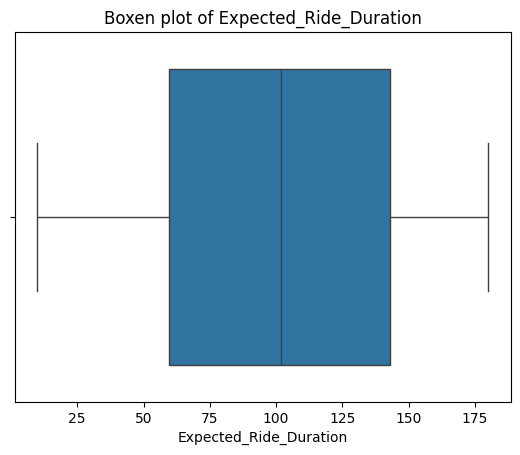

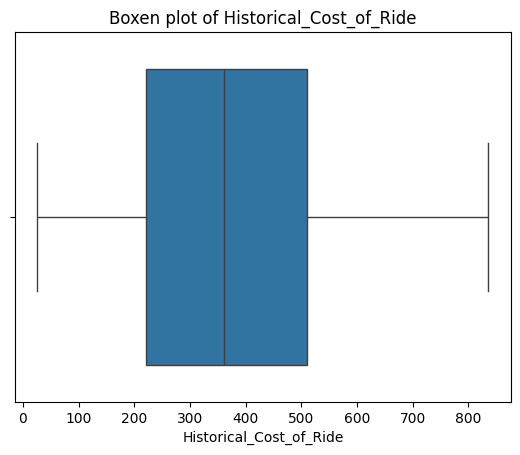

In [45]:
#checking the Outlinersby using boxplot
plt.figure(figsize=(10,6))
for column in df.select_dtypes(include=np.number).columns:
    sns.boxplot(x=df[column])
    plt.title(f'Boxen plot of {column}')
    plt.show()

In [46]:
# KEEPING THE OUTLINERS

#The outlier values (79–89) are realistic in urban/peak scenarios, not errors.
#They represent rare but important business cases (festivals, high-demand hours).
#Removing them would lose valuable information about extreme demand-supply conditions.
#We should keep them for a comprehensive analysis of ride patterns and pricing strategies.
#And our dataset is also small so removing it can be possible that our model will be can go to overfitting.

In [47]:
#Implimenting KPI's

#Gross Booking Value (GBV) Calculation
df['Revenue'] = df['Number_of_Riders'] * df['Historical_Cost_of_Ride']
print("Gross Booking Value (GBV):", df['Revenue'].sum())

#Average Revenue per Ride (ARPR) Calculation
ARPR = df['Revenue'].sum() / df['Number_of_Riders'].sum()
print("Average Revenue per Ride (ARPR):", ARPR)

#Demand-Supply Ratio (DSR) Calculation
df['DSR'] = df['Number_of_Riders'] / df['Number_of_Drivers']
print("Sample DSR values:\n", df['DSR'].head())

print("Average Demand-Supply Ratio:", df['DSR'].mean())

#Profit Margin Calculation
df['Cost'] = df['Historical_Cost_of_Ride'] * 0.7
df['Profit'] = df['Revenue'] - (df['Cost'] * df['Number_of_Riders'])
Profit_Margin = (df['Profit'].sum() / df['Revenue'].sum()) * 100
print("Profit Margin (%):", Profit_Margin)

#Average Rating KPI
print("Average Customer Rating:", df['Average_Ratings'].mean())

Gross Booking Value (GBV): 22514545.017633334
Average Revenue per Ride (ARPR): 372.9302494141876
Sample DSR values:
 0    2.000000
1    1.487179
2    1.354839
3    3.178571
4    3.545455
Name: DSR, dtype: float64
Average Demand-Supply Ratio: 3.2354611988674895
Profit Margin (%): 30.000000000000004
Average Customer Rating: 4.25722


In [48]:
df.head()

,Number_of_Riders,Number_of_Drivers,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride,Location_Category_Suburban,Location_Category_Urban,Time_of_Booking_Evening,Time_of_Booking_Morning,Time_of_Booking_Night,Vehicle_Type_Premium,Revenue,DSR,Cost,Profit
0,90,45,2,13,4.47,90,284.257273,False,True,False,False,True,True,25583.154572,2.000000,198.980091,7674.946372
1,58,39,2,72,4.06,43,173.874753,True,False,True,False,False,False,10084.735659,1.487179,121.712327,3025.420698
2,42,31,2,0,3.99,76,329.795469,False,False,False,False,False,True,13851.409696,1.354839,230.856828,4155.422909
3,89,28,1,67,4.31,134,470.201232,False,False,False,False,False,True,41847.909626,3.178571,329.140862,12554.372888
4,78,22,1,74,3.77,149,579.681422,False,False,False,False,False,False,45215.150944,3.545455,405.776996,13564.545283
